# 04 · Evaluasi final, hari 11

Satu model saja, yang terpilih. Notebook ini tidak melatih apa pun dan tidak
butuh GPU, jadi ia dijalankan di komputer sendiri bukan di Colab.

Empat hal dikerjakan di sini.

1. Evaluasi resmi di test set dengan `conf=0.001`, beserta confusion matrix dan
   kurva yang dihasilkan Ultralytics
2. Kecepatan di CPU, angka yang menentukan rasa aplikasi
3. **Sapuan confidence threshold**, diukur pada kualitas vonis bukan pada mAP
4. Analisis kegagalan, melihat dengan mata gambar mana yang salah dan kenapa

Bagian ketiga yang paling penting. Nilai `conf` bawaan aplikasi selama ini 0,25,
dan angka itu warisan dari Ultralytics bukan hasil pengukuran. Untuk sistem
keselamatan, ambang itu adalah keputusan yang menentukan berapa banyak orang
dituduh keliru dan berapa banyak pelanggar lolos, jadi ia layak diukur.


In [1]:
import glob, json, os, statistics, sys, time, zipfile
from pathlib import Path

sys.path.insert(0, "..")

import yaml
from PIL import Image
from ultralytics import YOLO

from skrip.validasi_analitik import muat_label, nilai_vonis
from src.analitik import LENGKAP, PERLU_DIPERIKSA, TIDAK_LENGKAP, asosiasi
from src.detector import daftar_model, deteksi, muat_model, siapkan_gambar

# Lokasi dataset, urutan yang sama dengan notebook 01.
KANDIDAT_ZIP = [
    "/content/drive/MyDrive/capstone4/construction safety.v1i.yolov12.zip",
    "construction safety.v1i.yolov12.zip",
    "../../pilihan dataset dan aturan/construction safety.v1i.yolov12.zip",
    "../pilihan dataset dan aturan/construction safety.v1i.yolov12.zip",
]
ROOT = "dataset"
if not os.path.isdir(ROOT):
    sumber = next((p for p in KANDIDAT_ZIP if os.path.exists(p)), None)
    if sumber is None:
        raise FileNotFoundError("Zip dataset tidak ditemukan, sesuaikan KANDIDAT_ZIP.")
    print("mengekstrak dari", sumber)
    with zipfile.ZipFile(sumber) as z:
        z.extractall(ROOT)

# Roboflow menulis path relatif, ditulis ulang menjadi absolut supaya tidak
# bergantung pada direktori kerja.
YAML = glob.glob(f"{ROOT}/*.yaml")[0]
cfg = yaml.safe_load(open(YAML))
for k, sub in [("train", "train"), ("val", "valid"), ("test", "test")]:
    cfg[k] = str(Path(ROOT, sub, "images").resolve())
with open(YAML, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False, allow_unicode=True)

# Model terpilih, yaitu bobot pertama yang juga menjadi bawaan aplikasi.
NAMA_MODEL = daftar_model()[0]
CATATAN = json.loads(
    Path("..", "laporan", f"{Path(NAMA_MODEL).stem.removeprefix('apd_')}_catatan.json")
    .read_text(encoding="utf-8")
)
IMGSZ = int(CATATAN["imgsz"])

LABEL_TEST = sorted(Path(ROOT, "test", "labels").glob("*.txt"))
print(f"model  {NAMA_MODEL}")
print(f"imgsz  {IMGSZ}, diambil dari catatan versinya bukan ditulis tangan")
print(f"test   {len(LABEL_TEST)} gambar")


model  apd_v3_oversample_nohelmet.pt
imgsz  960, diambil dari catatan versinya bukan ditulis tangan
test   90 gambar


## 1. Evaluasi resmi

`conf=0.001`, bukan 0,25. Ambang tinggi memotong ekor kurva precision recall
sehingga mAP terhitung lebih rendah daripada yang sebenarnya. Ini evaluasi
model, bukan simulasi pemakaian, jadi seluruh deteksi harus ikut dihitung.

Split yang dipakai **test**, bukan validation, karena validation dipakai
memilih checkpoint sehingga angkanya sudah menyesuaikan diri.


In [2]:
model = YOLO(str(Path("..", "models", NAMA_MODEL)))
metrik = model.val(data=YAML, split="test", imgsz=IMGSZ, conf=0.001, iou=0.7,
                   plots=True, verbose=False, project="runs_evaluasi", name="final",
                   exist_ok=True)

print(f"mAP@0.5       {metrik.box.map50:.4f}")
print(f"mAP@0.5:0.95  {metrik.box.map:.4f}")
print()
print(f"{'kelas':12} {'P':>8} {'R':>8} {'mAP50':>8} {'mAP50-95':>9}")
print("-" * 48)
per_kelas = {}
for i, n in enumerate(metrik.names.values()):
    per_kelas[n] = {
        "P": round(float(metrik.box.p[i]), 4),
        "R": round(float(metrik.box.r[i]), 4),
        "mAP50": round(float(metrik.box.ap50[i]), 4),
        "mAP50_95": round(float(metrik.box.ap[i]), 4),
    }
    print(f"{n:12} {metrik.box.p[i]:8.3f} {metrik.box.r[i]:8.3f} "
          f"{metrik.box.ap50[i]:8.3f} {metrik.box.ap[i]:9.3f}")

# Jalur diambil dari objek hasilnya, bukan ditebak. Ultralytics menaruh
# keluaran di bawah runs_dir miliknya sendiri, jadi `project` bukan jalur
# relatif terhadap direktori kerja seperti yang mudah dikira.
DIR_PLOT = Path(metrik.save_dir)
print()
print("berkas gambar disimpan di", DIR_PLOT)
for p in sorted(DIR_PLOT.glob("*.png")):
    print("  ", p.name)


Ultralytics 8.4.138 🚀 Python-3.13.9 torch-2.11.0 CPU (Apple M5)


YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 422.1±572.8 MB/s, size: 245.2 KB)


val: Scanning /Users/kukuhaulias/Projects/capstone-4/capstone4-apd-konstruksi/notebooks/dataset/test/labels.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 13.0Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 16% ━━────────── 1/6 11.0s/it 3.3s<55.1s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.6s/it 21.7s

                   all         90        623      0.752      0.711      0.686      0.334


Speed: 1.1ms preprocess, 229.5ms inference, 0.0ms loss, 0.5ms postprocess per image


Results saved to /Users/kukuhaulias/Projects/capstone-4/capstone4-apd-konstruksi/runs/detect/runs_evaluasi/final


mAP@0.5       0.6859
mAP@0.5:0.95  0.3340

kelas               P        R    mAP50  mAP50-95
------------------------------------------------
helmet          0.809    0.887    0.854     0.412
no-helmet       0.717    0.458    0.424     0.147
no-vest         0.628    0.635    0.616     0.243
person          0.790    0.846    0.818     0.477
vest            0.814    0.729    0.718     0.390

berkas gambar disimpan di /Users/kukuhaulias/Projects/capstone-4/capstone4-apd-konstruksi/runs/detect/runs_evaluasi/final
   BoxF1_curve.png
   BoxPR_curve.png
   BoxP_curve.png
   BoxR_curve.png
   confusion_matrix.png
   confusion_matrix_normalized.png


## 2. Confusion matrix dan kurva

Confusion matrix yang dinormalkan lebih mudah dibaca, karena kelas dengan
jumlah instance sangat berbeda tidak lagi saling menenggelamkan. Perhatikan
kolom `background`, itu yang memberi tahu kelas mana yang paling sering
terlewat begitu saja.


confusion_matrix_normalized.png


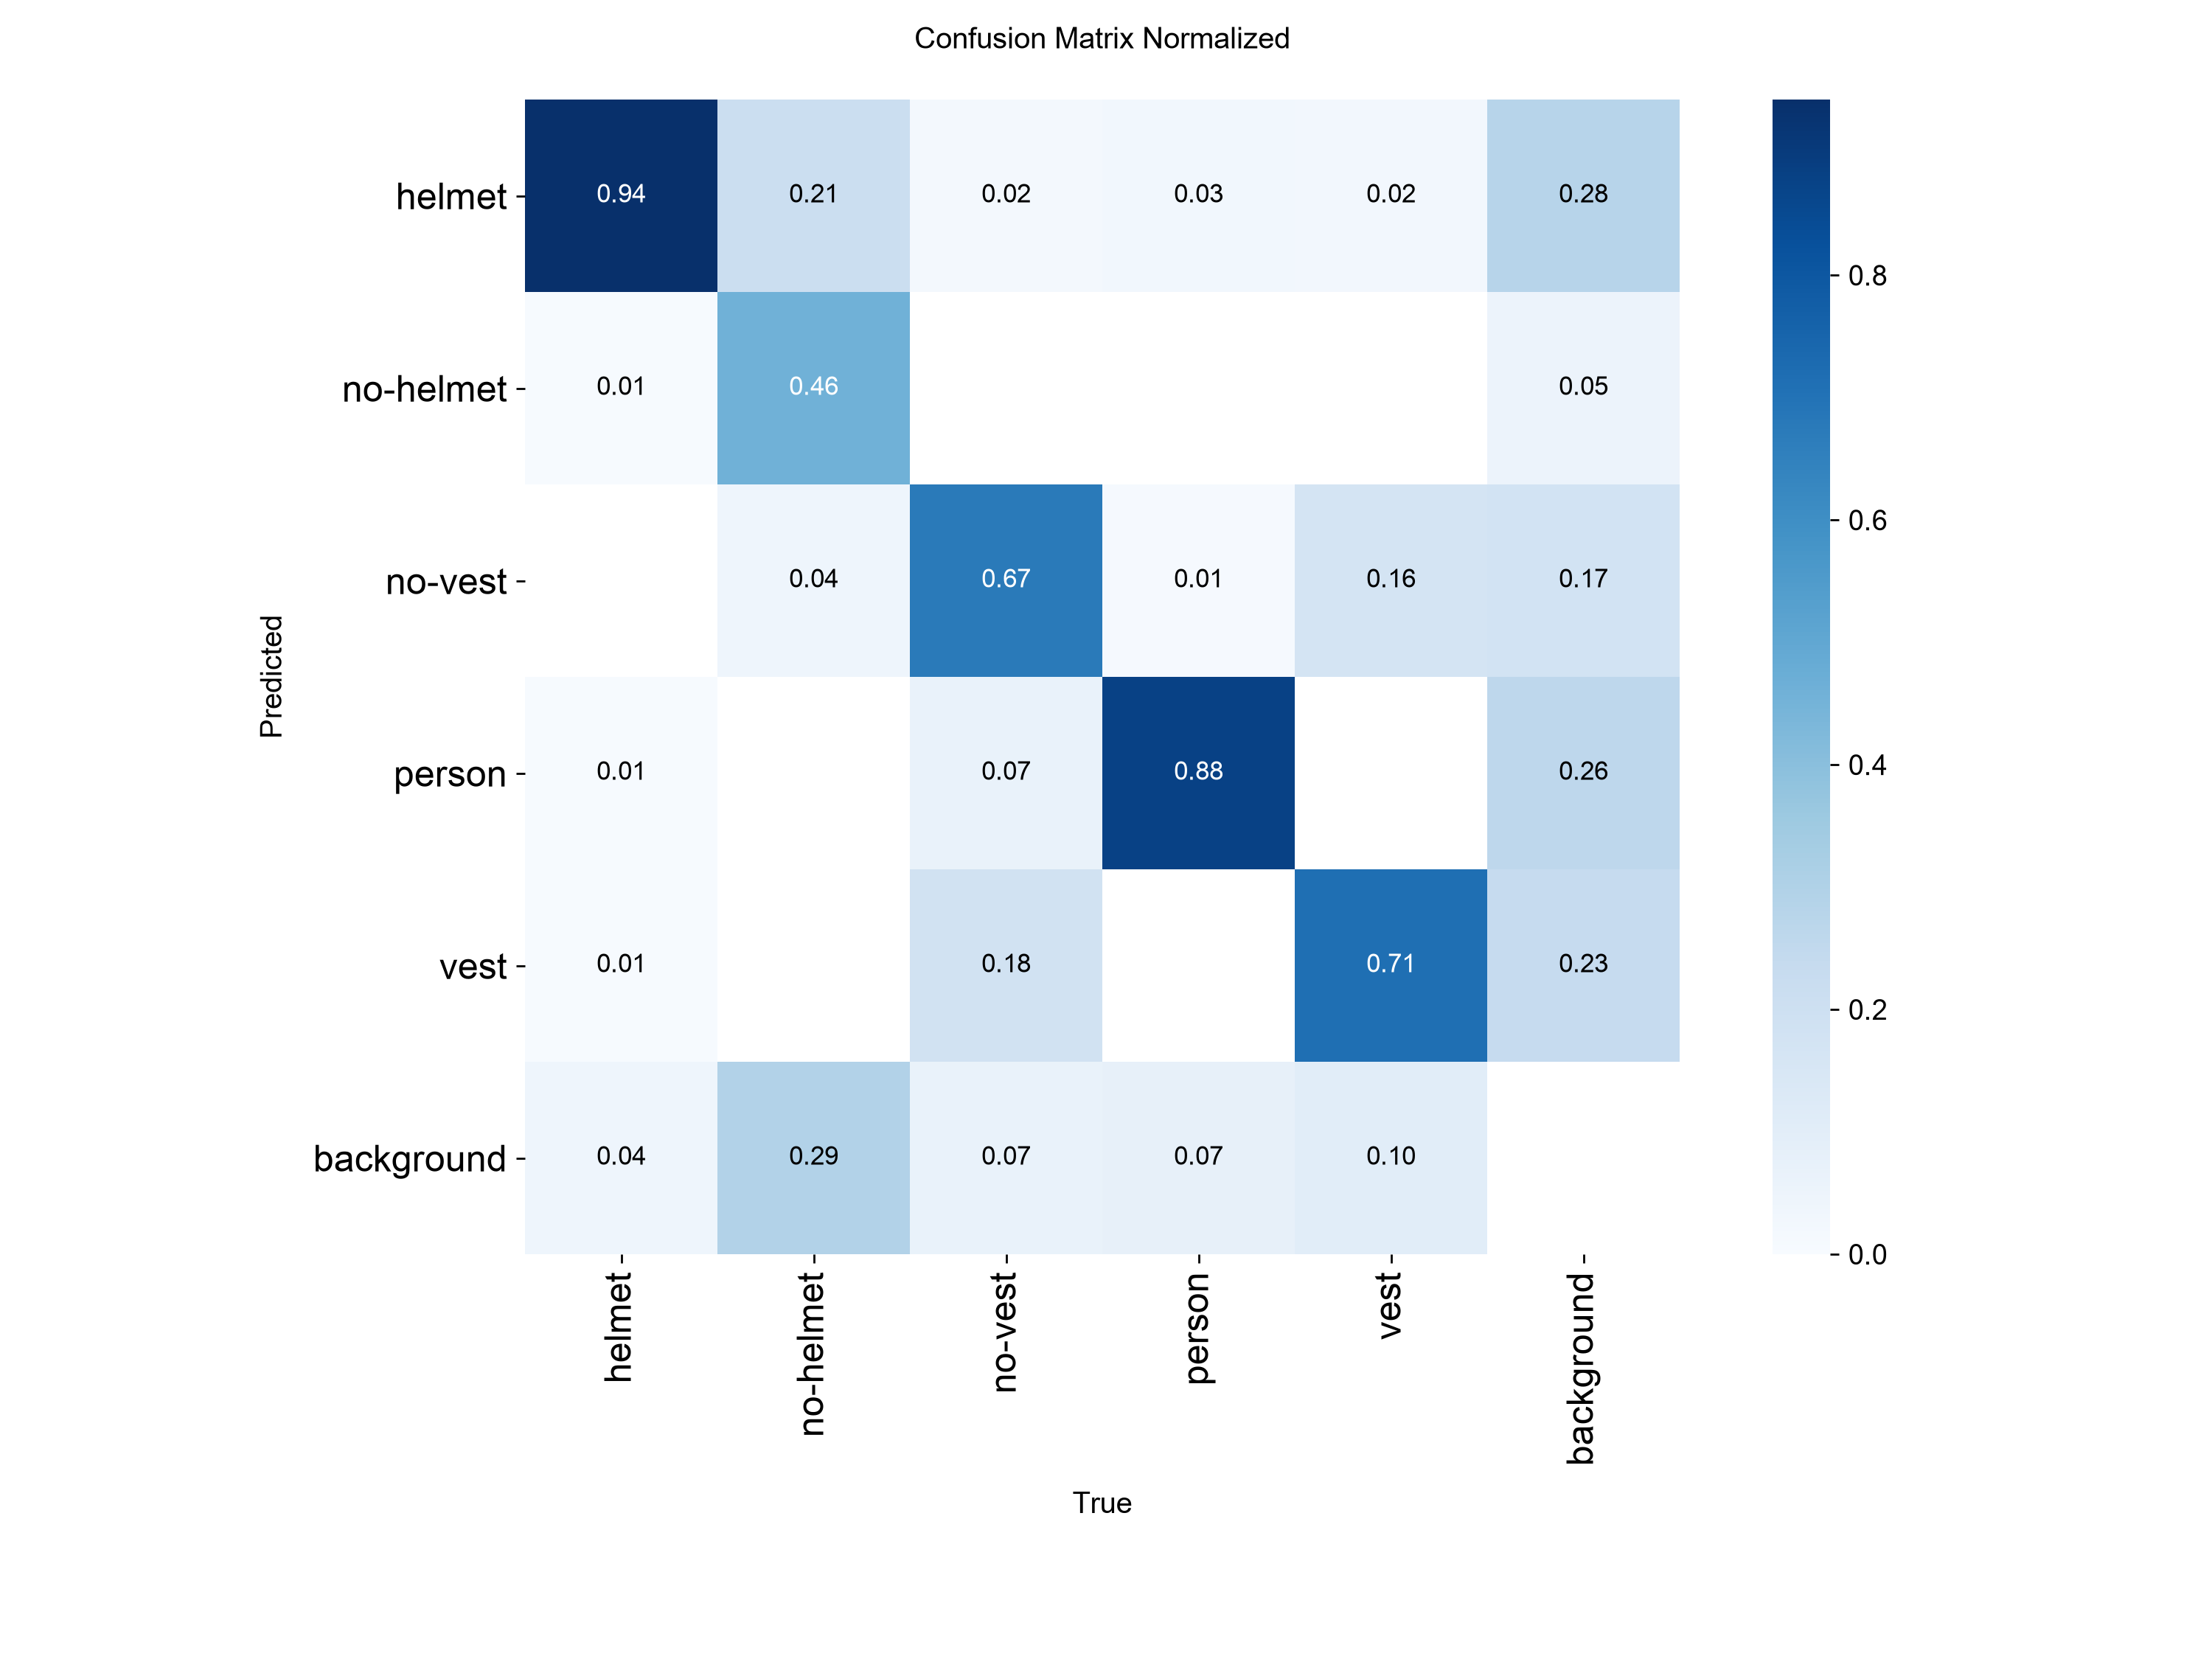

BoxPR_curve.png


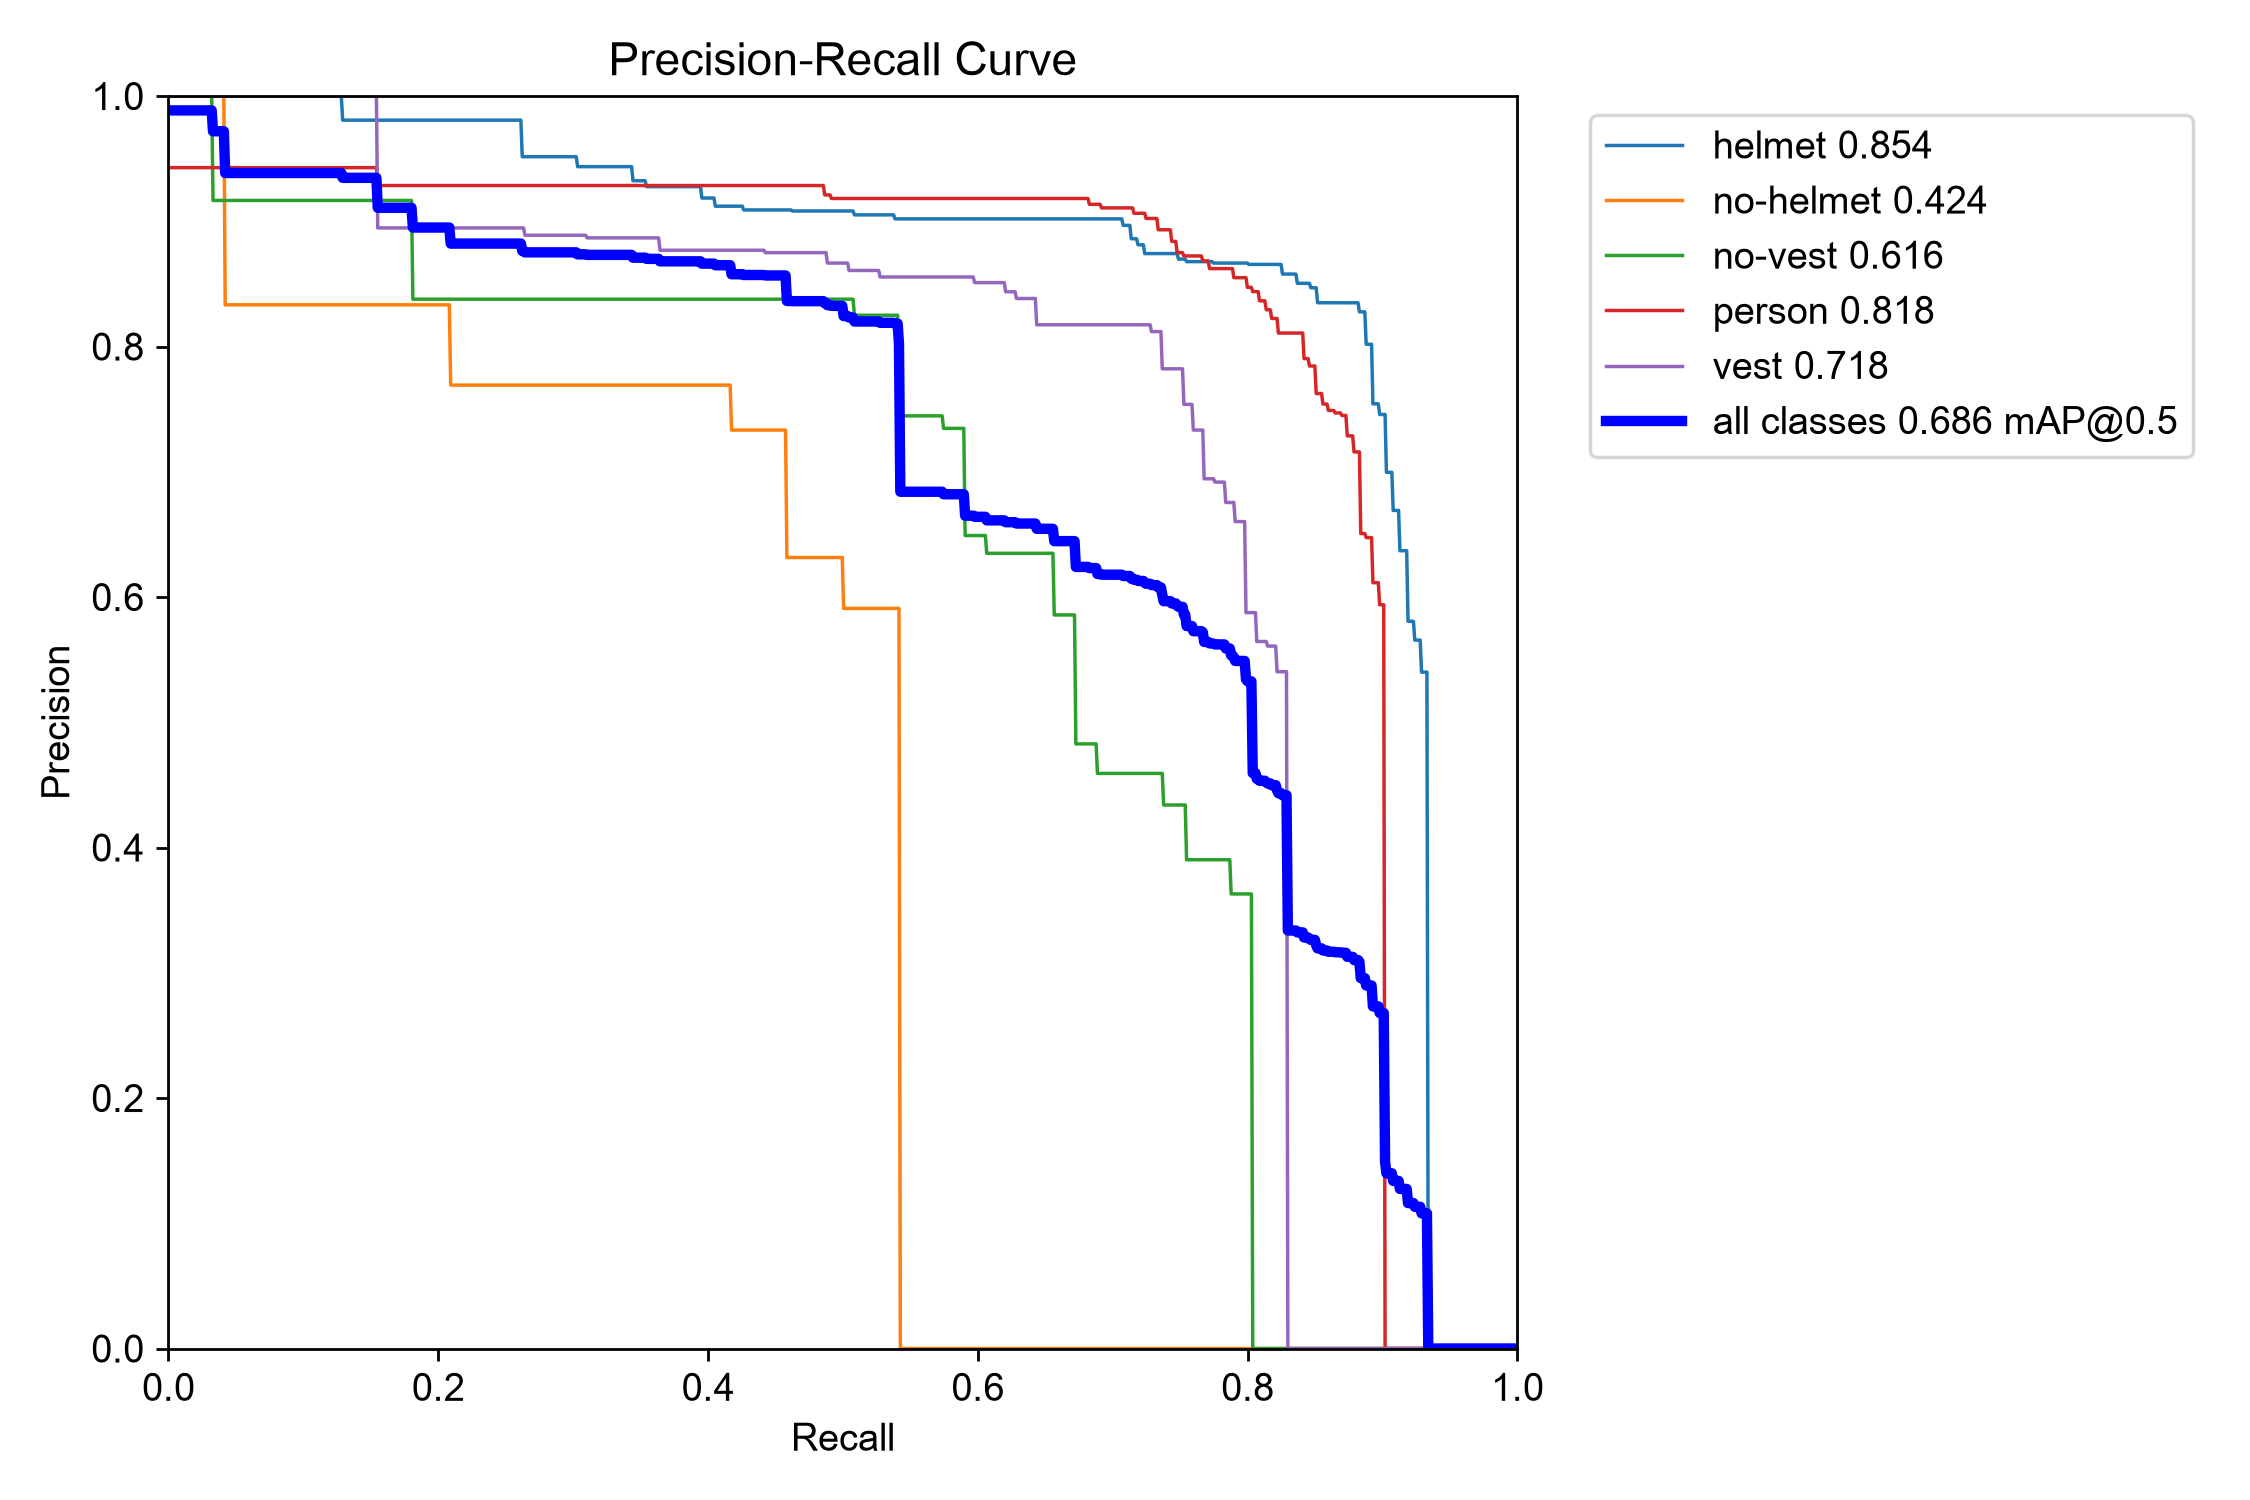

BoxF1_curve.png


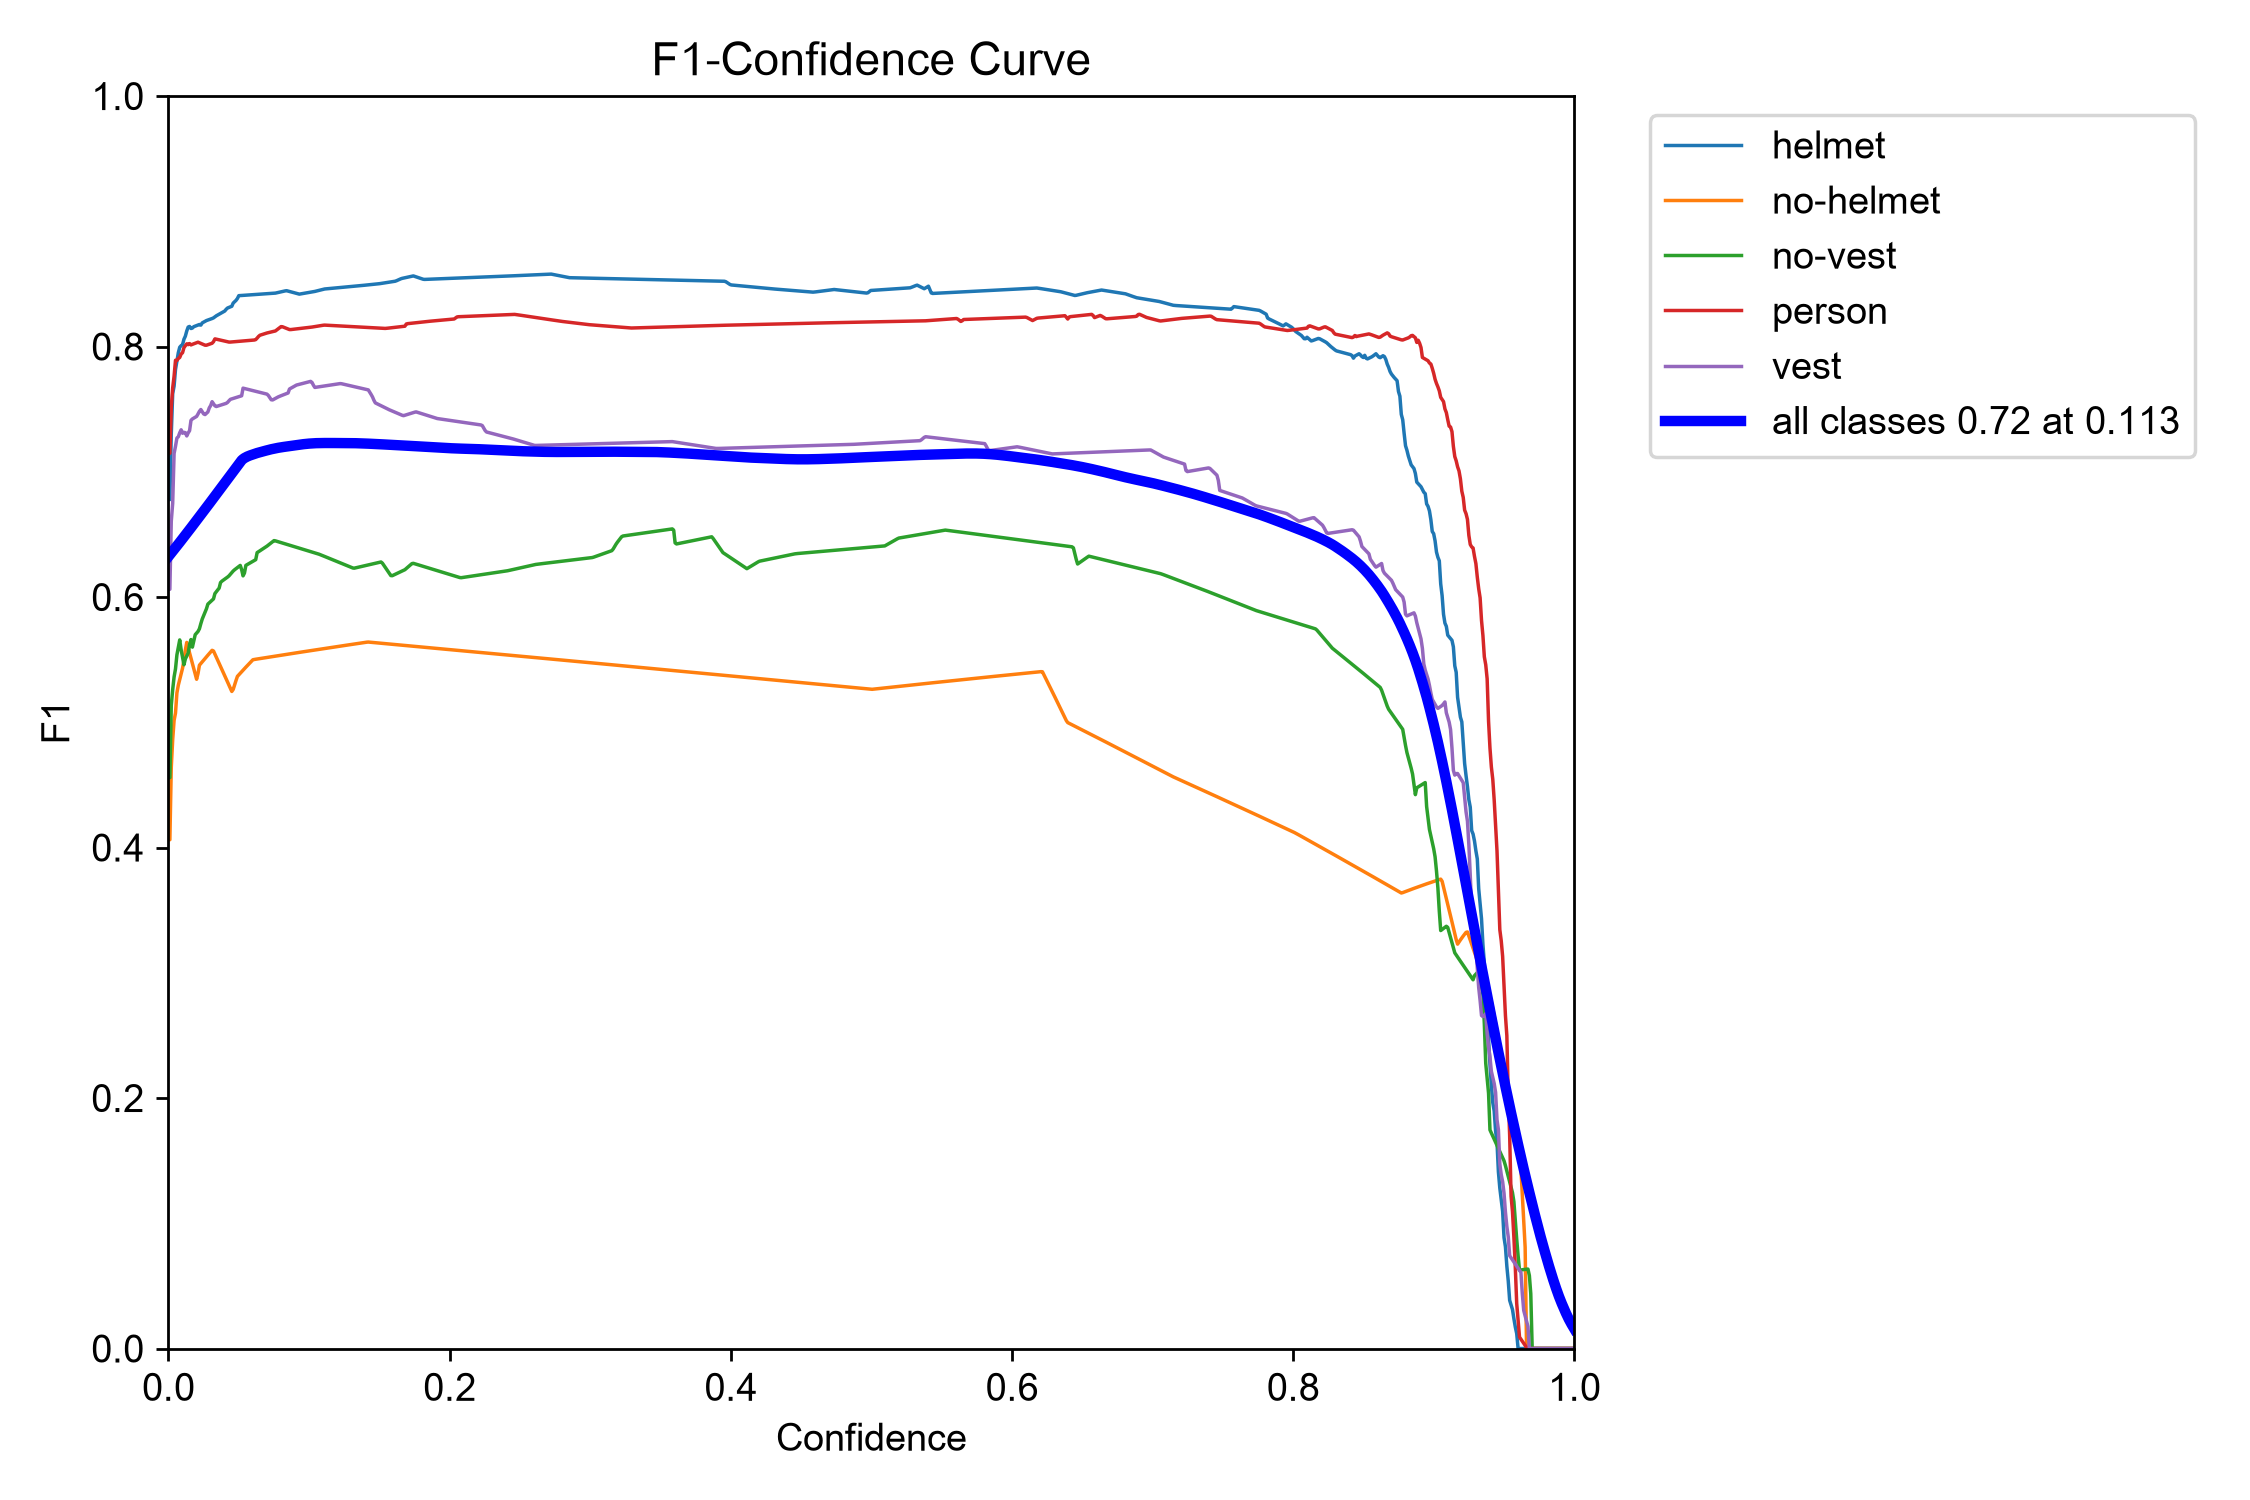

In [3]:
from IPython.display import Image as Tampil, display

# Dicocokkan dengan akhiran nama, bukan nama persis. Ultralytics 8.4 memberi
# awalan Box pada kurva, misalnya BoxPR_curve.png, dan awalan itu berubah
# antar versi. Mencocokkan akhiran membuat sel ini tidak diam-diam melewatkan
# gambarnya saat versinya naik.
for akhiran in ["confusion_matrix_normalized.png", "PR_curve.png", "F1_curve.png"]:
    cocok = sorted(DIR_PLOT.glob(f"*{akhiran}"))
    if not cocok:
        print(f"tidak ada berkas berakhiran {akhiran}")
        continue
    print(cocok[0].name)
    display(Tampil(filename=str(cocok[0]), width=760))


## 3. Kecepatan di CPU

Streamlit Community Cloud tidak punya GPU, jadi angka CPU yang menentukan rasa
aplikasi.

Panggilan pertama **diukur di proses terpisah**, dan itu bukan kerumitan yang
dibuat-buat. Sel evaluasi di atas sudah menjalankan model, sehingga lazy init
PyTorch di proses ini sudah lewat. Mengukurnya di sini akan melaporkan angka
hangat sambil menyebutnya angka dingin, keliru dengan cara yang tidak
kelihatan.


In [4]:
import subprocess, textwrap

contoh = sorted(Path("..", "contoh_gambar").glob("*.jpg"))
gambar_uji = siapkan_gambar(contoh[0])
m_cpu = muat_model(NAMA_MODEL)

# Panggilan pertama, di proses yang benar-benar baru.
skrip_dingin = textwrap.dedent(f"""
    import sys, time
    sys.path.insert(0, "..")
    from src.detector import deteksi, muat_model, siapkan_gambar
    g = siapkan_gambar({str(contoh[0])!r})
    m = muat_model({NAMA_MODEL!r})
    t0 = time.perf_counter()
    deteksi(m, g, conf=0.25, iou=0.7, imgsz={IMGSZ})
    print(round((time.perf_counter() - t0) * 1000))
""")
jalan = subprocess.run([sys.executable, "-c", skrip_dingin], capture_output=True, text=True)
pertama = int(jalan.stdout.strip().splitlines()[-1]) if jalan.returncode == 0 else None

# Panggilan berikutnya, di proses ini yang sudah hangat.
for _ in range(3):
    deteksi(m_cpu, gambar_uji, conf=0.25, iou=0.7, imgsz=IMGSZ)
waktu = []
for _ in range(15):
    t0 = time.perf_counter()
    deteksi(m_cpu, gambar_uji, conf=0.25, iou=0.7, imgsz=IMGSZ)
    waktu.append((time.perf_counter() - t0) * 1000)

median = statistics.median(waktu)
KECEPATAN = {
    "panggilan_pertama_proses_baru_ms": pertama,
    "median_ms": round(median, 1),
    "min_ms": round(min(waktu), 1),
    "maks_ms": round(max(waktu), 1),
    "val_batch16_ms_per_gambar": round(float(metrik.speed["inference"]), 1),
    "gpu_t4_ms": CATATAN.get("kecepatan_ms"),
}
print(json.dumps(KECEPATAN, indent=2, ensure_ascii=False))
print()
if pertama:
    print(f"panggilan pertama {pertama/median:.0f} kali median, lazy init PyTorch, "
          f"sekali per proses")
print()
print("Perhatikan dua angka yang berbeda dan keduanya benar.")
print(f"  {KECEPATAN['val_batch16_ms_per_gambar']} ms adalah angka dari model.val, batch 16")
print(f"  {KECEPATAN['median_ms']} ms adalah satu gambar sekali jalan")
print("Aplikasi memproses satu gambar sekali jalan, jadi angka kedua yang berlaku.")
print("Batch besar di CPU justru memperlambat per gambar, karena memorinya berebut.")


{
  "panggilan_pertama_proses_baru_ms": 748,
  "median_ms": 68.8,
  "min_ms": 55.8,
  "maks_ms": 76.6,
  "val_batch16_ms_per_gambar": 229.5,
  "gpu_t4_ms": {
    "preprocess": 2.9,
    "inference": 6.5,
    "loss": 0.0,
    "postprocess": 1.9
  }
}

panggilan pertama 11 kali median, lazy init PyTorch, sekali per proses

Perhatikan dua angka yang berbeda dan keduanya benar.
  229.5 ms adalah angka dari model.val, batch 16
  68.8 ms adalah satu gambar sekali jalan
Aplikasi memproses satu gambar sekali jalan, jadi angka kedua yang berlaku.
Batch besar di CPU justru memperlambat per gambar, karena memorinya berebut.


## 4. Sapuan confidence, diukur pada kualitas vonis

Ini bagian terpenting notebook ini.

`conf=0.25` adalah nilai bawaan Ultralytics, bukan hasil pengukuran pada kasus
ini. Untuk sistem yang menjatuhkan vonis tentang orang, ambang itu menentukan
tiga hal sekaligus yang biayanya sangat berbeda, berapa pelanggar lolos, berapa
orang patuh dituduh, dan berapa banyak yang dilempar ke pemeriksaan manusia.

Modelnya dijalankan **sekali saja** pada ambang sangat rendah, lalu deteksinya
disaring di Python untuk tiap ambang. Menaikkan `conf` memang hanya menyaring,
dan NMS memproses kotak dari confidence tertinggi sehingga kotak yang bertahan
di ambang tinggi tidak berubah oleh kehadiran kotak berconfidence rendah.

Penilaian tiap ambang memakai `nilai_vonis` dari `skrip/validasi_analitik.py`,
fungsi yang sama persis dengan yang dipakai laporan, bukan salinannya.


In [5]:
CONF_SAPU = 0.01     # serendah mungkin, penyaringan dilakukan setelahnya

acuan_dan_prediksi = []
for jalur_label in LABEL_TEST:
    jalur_gambar = next(
        (g for e in (".jpg", ".jpeg", ".png")
         if (g := jalur_label.parent.parent / "images" / (jalur_label.stem + e)).exists()),
        None,
    )
    if jalur_gambar is None:
        continue
    with Image.open(jalur_gambar) as im:
        g = im.convert("RGB")
        lebar, tinggi = g.size
        mentah, _ = deteksi(m_cpu, g, conf=CONF_SAPU, iou=0.7, imgsz=IMGSZ)
    prediksi = [
        {"cls": d["cls"], "conf": d["conf"],
         "box": (d["box"][0] / lebar, d["box"][1] / tinggi,
                 d["box"][2] / lebar, d["box"][3] / tinggi)}
        for d in mentah
    ]
    acuan_dan_prediksi.append((jalur_label.name, prediksi, asosiasi(muat_label(jalur_label))))

print(f"{len(acuan_dan_prediksi)} gambar, "
      f"{sum(len(p) for _, p, _ in acuan_dan_prediksi)} deteksi mentah pada conf {CONF_SAPU}")


90 gambar, 734 deteksi mentah pada conf 0.01


In [6]:
AMBANG = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70]

sapuan = []
for t in AMBANG:
    pasangan = [
        (asosiasi([d for d in prediksi if d["conf"] >= t]), acuan)
        for _, prediksi, acuan in acuan_dan_prediksi
    ]
    m = nilai_vonis(pasangan)
    m["conf"] = t
    sapuan.append(m)

kolom = [("conf", "conf"), ("cakupan_pekerja", "cakupan"),
         ("laju_pembebasan_keliru", "bebas keliru"), ("laju_tuduhan_palsu", "tuduh palsu"),
         ("porsi_perlu_pemeriksaan_manusia", "perlu manusia"),
         ("akurasi_vonis", "akurasi"), ("pekerja_palsu", "pekerja palsu")]
print("  ".join(f"{j:>13}" for _, j in kolom))
print("-" * (15 * len(kolom)))
for r in sapuan:
    print("  ".join(f"{r.get(k) if r.get(k) is not None else '-':>13}" for k, _ in kolom))


         conf        cakupan   bebas keliru    tuduh palsu  perlu manusia        akurasi  pekerja palsu
---------------------------------------------------------------------------------------------------------
         0.05         0.8598          0.069         0.0291         0.2554          0.712             50
          0.1         0.8551         0.0526         0.0194         0.2787         0.7104             46
         0.15         0.8551         0.0526         0.0194         0.3005         0.6885             43
          0.2         0.8458         0.0526         0.0198         0.3149          0.674             42
         0.25         0.8411         0.0357         0.0198         0.3389         0.6667             40
          0.3         0.8364         0.0357         0.0198         0.3464         0.6536             37
         0.35         0.8364         0.0357         0.0198         0.3575         0.6425             35
          0.4         0.8318         0.0357         0.0198    

### Membaca tabel itu

Dua kolom bergerak jelas, dan keduanya berlawanan arah.

**Menurunkan `conf` mengurangi beban pemeriksaan manusia.** Dari 44,5 persen di
0,70 menjadi 25,5 persen di 0,05. Masuk akal, sebab lebih banyak atribut
tertangkap sehingga lebih sedikit pekerja yang statusnya menggantung.

**Tapi menurunkan `conf` menambah pekerja palsu.** Dari 26 di 0,70 menjadi 50
di 0,05. Kotak person palsu menghasilkan baris di tabel kepatuhan yang tidak
merujuk siapa pun, dan itu membuang waktu pengawas dengan cara yang berbeda.

**Kedua laju kesalahan justru hampir datar.** Tuduhan palsu bertahan di sekitar
2 persen sepanjang 0,10 sampai 0,60. Pembebasan keliru turun dari 6,9 persen di
0,05 ke 3,6 persen di 0,25, lalu **berhenti membaik** sampai 0,70.

### Keputusan, dan kenapa 0,25 dipertahankan

Nilai bawaan Ultralytics ternyata pilihan yang baik di sini, tapi sekarang kita
bisa mengatakan alasannya, bukan sekadar mewarisinya.

`conf=0,25` adalah **titik awal dataran** tempat pembebasan keliru sudah
mencapai nilai terendahnya, 3,6 persen. Menaikkannya lebih jauh tidak
memperbaiki kesalahan apa pun, hanya menambah beban pemeriksaan manusia, dari
33,9 persen di 0,25 menjadi 44,5 persen di 0,70. Menurunkannya ke 0,10
mengurangi beban ke 27,9 persen tapi menaikkan pembebasan keliru dari 2 menjadi
3 pekerja.

Selisih dua lawan tiga pekerja dari 56 tidak dapat dipisahkan dari kebetulan,
jadi 0,10 sebenarnya juga bisa dipertahankan. Yang dipilih 0,25 karena pada
sistem keselamatan, saat dua pilihan sama-sama masuk akal, yang diambil adalah
yang lebih ketat terhadap kesalahan termahal.

Slider di aplikasi tetap ada, dan sekarang pengawas punya tabel ini untuk
menggesernya secara sadar.


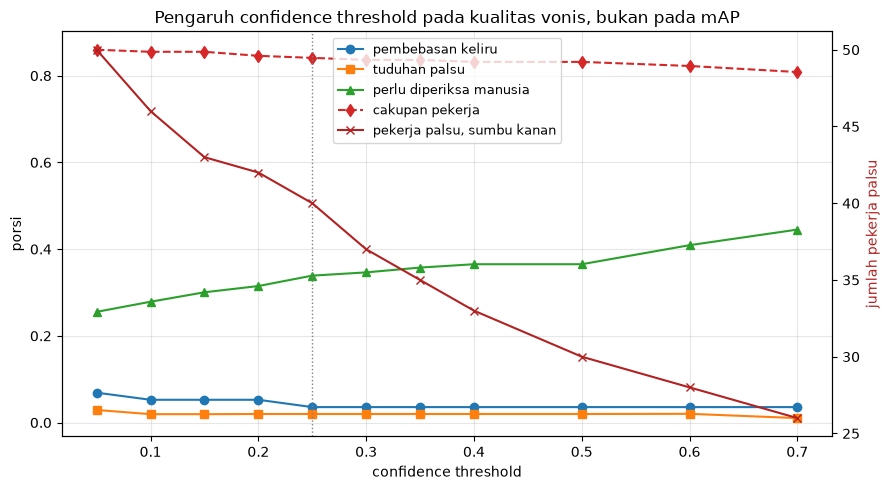

In [7]:
import matplotlib.pyplot as plt

x = [r["conf"] for r in sapuan]
fig, kiri = plt.subplots(figsize=(9, 5))

for kunci, label, gaya in [
    ("laju_pembebasan_keliru", "pembebasan keliru", "o-"),
    ("laju_tuduhan_palsu", "tuduhan palsu", "s-"),
    ("porsi_perlu_pemeriksaan_manusia", "perlu diperiksa manusia", "^-"),
    ("cakupan_pekerja", "cakupan pekerja", "d--"),
]:
    kiri.plot(x, [r.get(kunci) or 0 for r in sapuan], gaya, label=label)

kiri.set_xlabel("confidence threshold")
kiri.set_ylabel("porsi")
kiri.grid(alpha=0.3)
kiri.axvline(0.25, color="grey", linestyle=":", linewidth=1)
kiri.annotate("bawaan 0,25", (0.25, 0.92), fontsize=9, color="grey")

kanan = kiri.twinx()
kanan.plot(x, [r["pekerja_palsu"] for r in sapuan], "x-", color="firebrick",
           label="pekerja palsu, sumbu kanan")
kanan.set_ylabel("jumlah pekerja palsu", color="firebrick")

garis = kiri.get_legend_handles_labels()[0] + kanan.get_legend_handles_labels()[0]
nama = kiri.get_legend_handles_labels()[1] + kanan.get_legend_handles_labels()[1]
kiri.legend(garis, nama, loc="upper center", fontsize=9)
plt.title("Pengaruh confidence threshold pada kualitas vonis, bukan pada mAP")
plt.tight_layout()
plt.show()


## 5. Analisis kegagalan

Angka agregat memberi tahu berapa banyak yang salah, tidak memberi tahu
kenapa. Bagian ini mengambil gambar dengan kesalahan vonis terbanyak pada
ambang yang dipakai aplikasi, lalu melihatnya.

Dua jenis kesalahan diberi bobot lebih berat, pembebasan keliru dan tuduhan
palsu, karena keduanya adalah pernyataan yang salah tentang seseorang.
Kesalahan yang berakhir di "belum dapat dipastikan" tidak dihitung berat,
sebab ia meminta manusia memeriksa dan tidak mengarang kesimpulan.


In [8]:
from skrip.validasi_analitik import pasangkan

CONF_APP = 0.25
rapor = []
for nama, prediksi, acuan in acuan_dan_prediksi:
    hasil = asosiasi([d for d in prediksi if d["conf"] >= CONF_APP])
    berat = ringan = 0
    rincian = []
    for i, j in pasangkan(hasil.pekerja, acuan.pekerja):
        vp, va = hasil.pekerja[i].vonis, acuan.pekerja[j].vonis
        if vp == va:
            continue
        parah = (va == TIDAK_LENGKAP and vp == LENGKAP) or (va == LENGKAP and vp == TIDAK_LENGKAP)
        berat += parah
        ringan += not parah
        rincian.append(f"#{hasil.pekerja[i].nomor} acuan {va} tapi diduga {vp}")
    rapor.append({"gambar": nama, "berat": berat, "ringan": ringan, "rincian": rincian})

rapor.sort(key=lambda r: (-r["berat"], -r["ringan"]))
print(f"gambar dengan kesalahan berat : {sum(1 for r in rapor if r['berat'])}")
print(f"total kesalahan berat         : {sum(r['berat'] for r in rapor)}")
print(f"total kesalahan ringan        : {sum(r['ringan'] for r in rapor)}")
print()
for r in rapor[:5]:
    if not r["berat"] and not r["ringan"]:
        break
    print(f"{r['gambar'][:46]:48} berat {r['berat']}  ringan {r['ringan']}")
    for x in r["rincian"][:4]:
        print(f"    {x}")


gambar dengan kesalahan berat : 4
total kesalahan berat         : 4
total kesalahan ringan        : 56

ppe_0720_jpg.rf.6e908f9bc5249819bf76436949c76a   berat 1  ringan 4
    #2 acuan LENGKAP tapi diduga BELUM DAPAT DIPASTIKAN
    #12 acuan LENGKAP tapi diduga TIDAK LENGKAP
    #7 acuan LENGKAP tapi diduga BELUM DAPAT DIPASTIKAN
    #3 acuan LENGKAP tapi diduga BELUM DAPAT DIPASTIKAN
ppe_0120_jpg.rf.53fa2f12be46d135ccd480c838d0da   berat 1  ringan 0
    #1 acuan TIDAK LENGKAP tapi diduga LENGKAP
ppe_0403_jpg.rf.9213e1b56dd961515b0979352b134f   berat 1  ringan 0
    #1 acuan TIDAK LENGKAP tapi diduga LENGKAP
ppe_0498_jpg.rf.a083f26289f80105edb0ce8cf74c03   berat 1  ringan 0
    #1 acuan LENGKAP tapi diduga TIDAK LENGKAP
ppe_0857_jpg.rf.67f5018b277da56c60e1b58ff7340e   berat 0  ringan 4
    #2 acuan BELUM DAPAT DIPASTIKAN tapi diduga TIDAK LENGKAP
    #3 acuan BELUM DAPAT DIPASTIKAN tapi diduga TIDAK LENGKAP
    #4 acuan BELUM DAPAT DIPASTIKAN tapi diduga TIDAK LENGKAP
    #1 acuan BELUM

ppe_0720_jpg.rf.6e908f9bc5249819bf76436949c76a3c.txt   kesalahan berat 1
    #2 acuan LENGKAP tapi diduga BELUM DAPAT DIPASTIKAN
    #12 acuan LENGKAP tapi diduga TIDAK LENGKAP
    #7 acuan LENGKAP tapi diduga BELUM DAPAT DIPASTIKAN
    #3 acuan LENGKAP tapi diduga BELUM DAPAT DIPASTIKAN
    #5 acuan LENGKAP tapi diduga BELUM DAPAT DIPASTIKAN


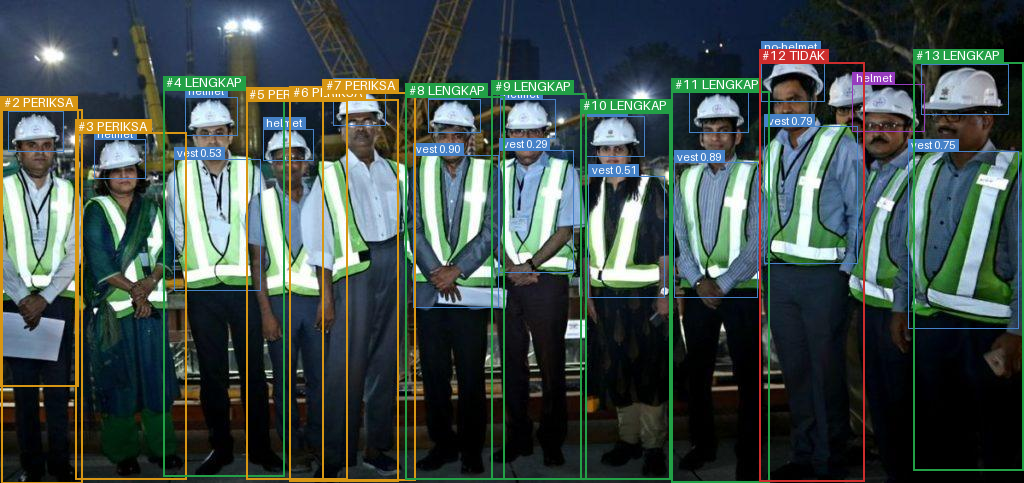

ppe_0120_jpg.rf.53fa2f12be46d135ccd480c838d0da1c.txt   kesalahan berat 1
    #1 acuan TIDAK LENGKAP tapi diduga LENGKAP


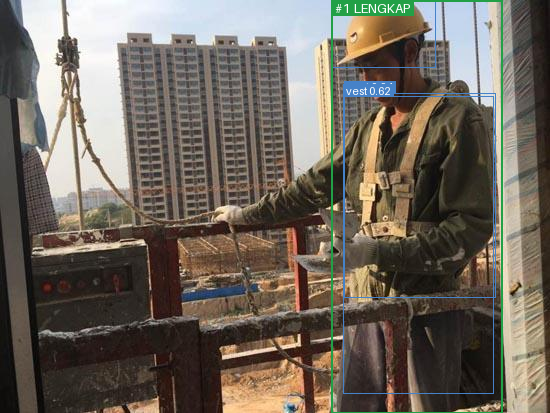

In [9]:
from src.tampilan import gambar_vonis

terburuk = [r for r in rapor if r["berat"]][:2]
for r in terburuk:
    jalur = Path(ROOT, "test", "images", r["gambar"].replace(".txt", ".jpg"))
    if not jalur.exists():
        continue
    g = siapkan_gambar(jalur)
    det, _ = deteksi(m_cpu, g, conf=CONF_APP, iou=0.7, imgsz=IMGSZ)
    print(f"{r['gambar'][:60]}   kesalahan berat {r['berat']}")
    for x in r["rincian"]:
        print("   ", x)
    display(gambar_vonis(g, asosiasi(det)))


## 6. Menyimpan angkanya

Satu berkas json, supaya README dan notebook mengutip sumber yang sama.


In [10]:
ringkas = {
    "model": NAMA_MODEL,
    "imgsz": IMGSZ,
    "split": "test",
    "conf_evaluasi": 0.001,
    "map50": round(float(metrik.box.map50), 4),
    "map50_95": round(float(metrik.box.map), 4),
    "per_kelas": per_kelas,
    "kecepatan": KECEPATAN,
    "conf_aplikasi": CONF_APP,
    "sapuan_conf": [
        {k: r.get(k) for k in
         ("conf", "cakupan_pekerja", "laju_pembebasan_keliru", "laju_tuduhan_palsu",
          "porsi_perlu_pemeriksaan_manusia", "akurasi_vonis", "pekerja_palsu",
          "pekerja_terpasangkan")}
        for r in sapuan
    ],
    "kegagalan": {
        "gambar_dengan_kesalahan_berat": sum(1 for r in rapor if r["berat"]),
        "total_kesalahan_berat": sum(r["berat"] for r in rapor),
        "total_kesalahan_ringan": sum(r["ringan"] for r in rapor),
        "terburuk": [
            {"gambar": r["gambar"], "berat": r["berat"], "ringan": r["ringan"],
             "rincian": r["rincian"]}
            for r in rapor[:5] if r["berat"] or r["ringan"]
        ],
    },
}
jalur = Path("..", "laporan", "evaluasi_final.json")
jalur.write_text(json.dumps(ringkas, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"ditulis ke laporan/{jalur.name}")
print(f"{len(sapuan)} baris sapuan, {len(ringkas['kegagalan']['terburuk'])} gambar terburuk dicatat")


ditulis ke laporan/evaluasi_final.json
11 baris sapuan, 5 gambar terburuk dicatat


## Yang sengaja tidak dikerjakan di sini

**Mengubah model.** Hari 11 mengevaluasi, tidak melatih. Kalau evaluasi ini
memunculkan ide perbaikan, ia dicatat sebagai keterbatasan, bukan dikerjakan
sekarang, karena mengubah model berarti seluruh angka di laporan harus dihitung
ulang dan waktunya tidak ada.

**Mengevaluasi di validation split.** Validation dipakai memilih checkpoint,
jadi angkanya sudah menyesuaikan diri dan akan terbaca lebih bagus daripada
kenyataannya.

**Menyembunyikan gambar yang gagal.** Bagian 5 justru mencarinya dengan
sengaja. Penilai akan menemukannya di confusion matrix, dan lebih baik kita
yang menunjukkannya lebih dulu beserta penjelasannya.
